# ITS Predict

In [1]:
%pip install -qq --ignore-requires-python --no-deps 'graphies[predict] @ git+https://github.com/lukasmki/graphies.git'
%pip install -qq pydantic networkx datasets polars torch

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print(
        "CUDA is not available. Please ensure you have selected a GPU runtime in 'Runtime > Change runtime type'."
    )

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device name: NVIDIA A100-SXM4-40GB


## Setup Data Sources

In [2]:
!mkdir -p its-nomod-data
!wget -nv https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/its-nomod.json -O its-nomod-data/its-nomod.json

from pathlib import Path

GRAMMAR_PATH = next(Path().glob("its-nomod-data/*.json"))

2026-04-25 00:21:04 URL:https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/its-nomod.json [7073/7073] -> "its-nomod-data/its-nomod.json" [1]


In [ ]:
from datasets import load_dataset

hf_dataset = load_dataset("lukaskim/MappedCRD", "its-nomod", split="train")

## Setup Data Loaders

In [4]:
from graphies.predict import GraphiesTokenizer, HFGraphiesDataset
from torch.utils.data import DataLoader, random_split

tokenizer = GraphiesTokenizer(GRAMMAR_PATH)
dataset = HFGraphiesDataset(
    hf_dataset, column="its_graphies", tokenizer=tokenizer, split=None
)

trn, tst = random_split(dataset, [0.9, 0.1])
torch.save(
    {"trn_indices": trn.indices, "tst_indices": tst.indices}, "its-nomod-data/split.pt"
)
trn_loader = DataLoader(
    dataset=trn,
    batch_size=256,
    shuffle=True,
    collate_fn=tokenizer.collate,
)
tst_loader = DataLoader(
    dataset=tst,
    batch_size=256,
    shuffle=False,
    collate_fn=tokenizer.collate,
)

## Trainer

In [5]:
from graphies.predict import GraphiesTrainer
from graphies.predict.models import GRU
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRU(vocab_size=tokenizer.vocab_size)
optimizer = Adam(params=model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.1)

# include kwargs for classes to restart from checkpoitn
checkpoint = {
    "model_kwargs": {"vocab_size": tokenizer.vocab_size},
    "optimizer_kwargs": {"lr": 1e-3},
    "scheduler_kwargs": {"mode": "min", "patience": 3, "factor": 0.1},
}
trainer = GraphiesTrainer(model, optimizer, scheduler, device, checkpoint)

In [6]:
trainer.train(
    train=trn_loader,
    epochs=2,
    test=tst_loader,
    test_interval=1,
    log="its-nomod-data/log.csv",
    log_interval=1,
    checkpoint="its-nomod-data/chk.pt",
    checkpoint_interval=1,
)
trainer.save_model("its-nomod-data/model.pt")

Test 2: 100%|██████████| 549/549 [00:23<00:00, 23.62it/s, loss=0.9925]


In [7]:
# export to google drive
from google.colab import drive

drive.mount("/content/drive")
!zip -r its-nomod-data.zip its-nomod-data/
!cp its-nomod-data.zip '/content/drive/MyDrive/'

Mounted at /content/drive
  adding: its-nomod-data/ (stored 0%)
  adding: its-nomod-data/0-chk.pt (deflated 11%)
  adding: its-nomod-data/log.csv (deflated 23%)
  adding: its-nomod-data/1-chk.pt (deflated 11%)
  adding: its-nomod-data/its-nomod.json (deflated 88%)
  adding: its-nomod-data/model.pt (deflated 7%)
  adding: its-nomod-data/split.pt (deflated 31%)


# Run Inference

In [8]:
from graphies.predict import GraphiesModel

model = GraphiesModel.from_checkpoint(
    checkpoint="its-nomod-data/model.pt",
    tokenizer=tokenizer,
    model_cls=GRU,
    device=device,
)
sequences = model.generate(num=16, temperature=0.9, top_p=0.95, max_len=200)
ref_sequences = hf_dataset[tst.indices]["its_graphies"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 691.9/691.9 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 71.1 MB/s eta 0:00:00


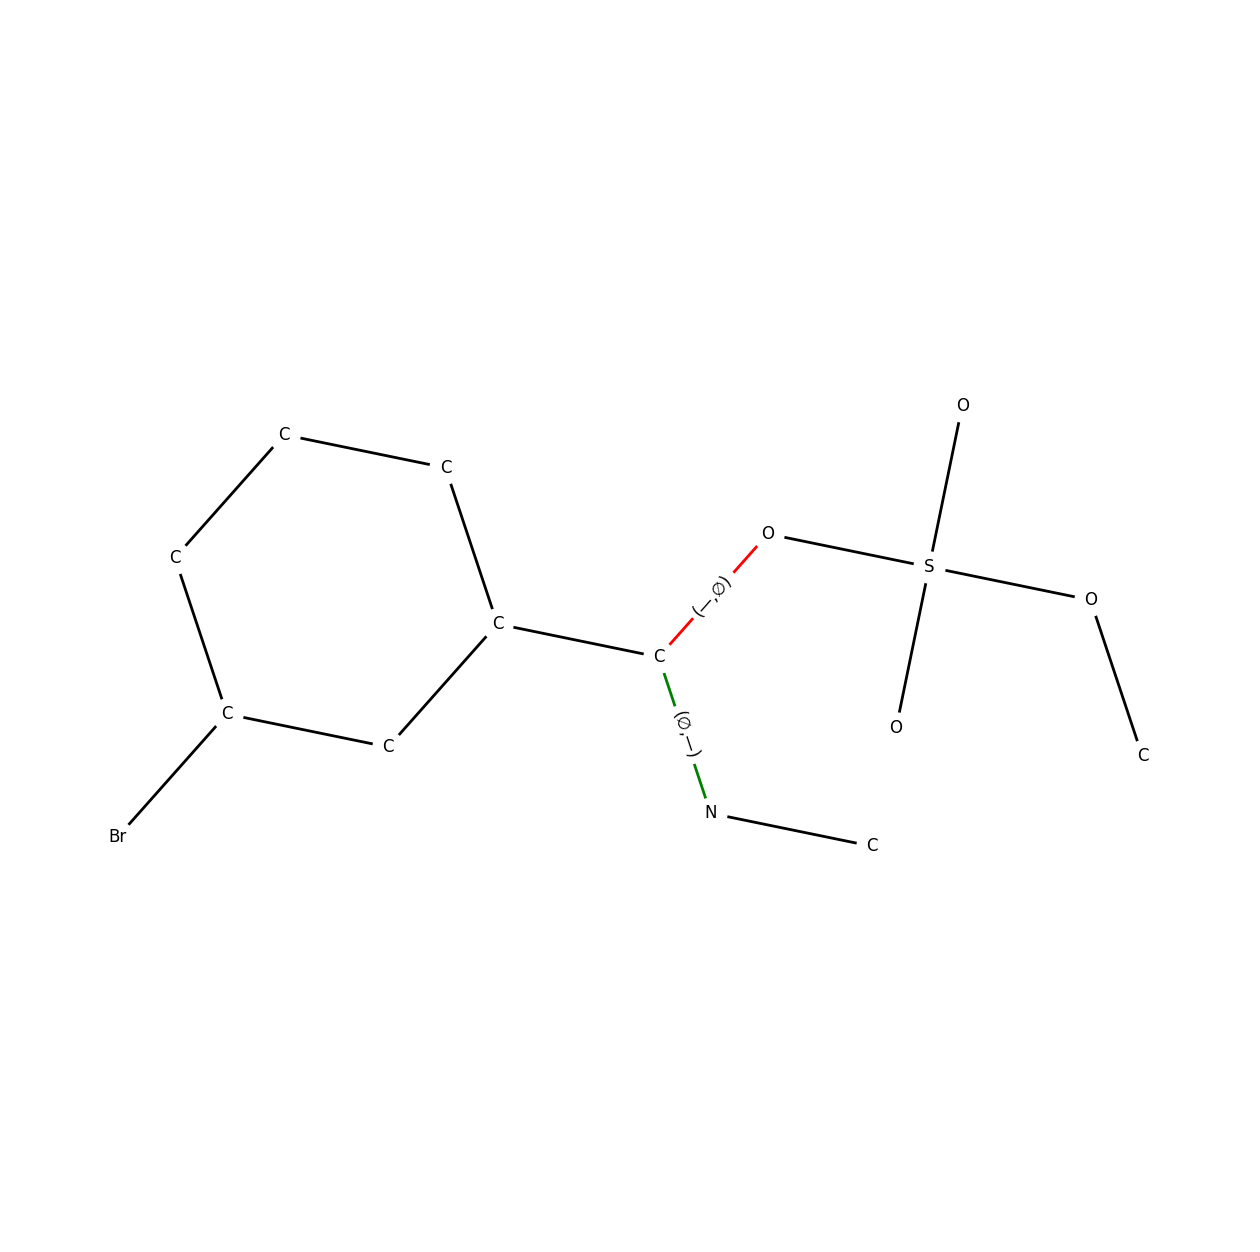

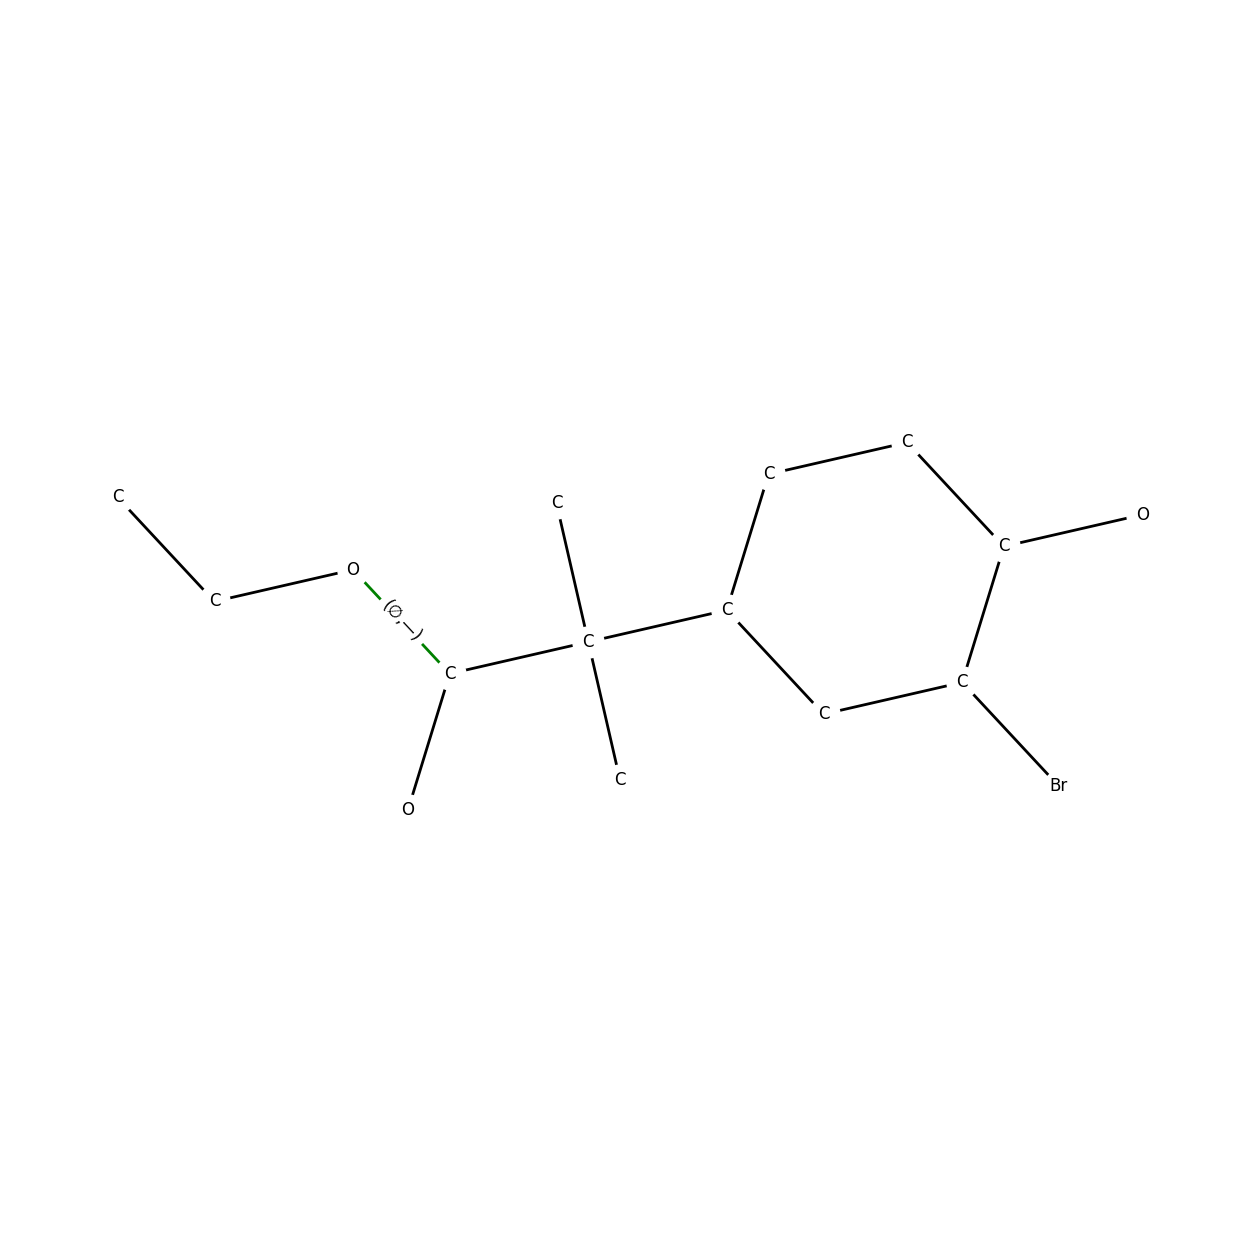

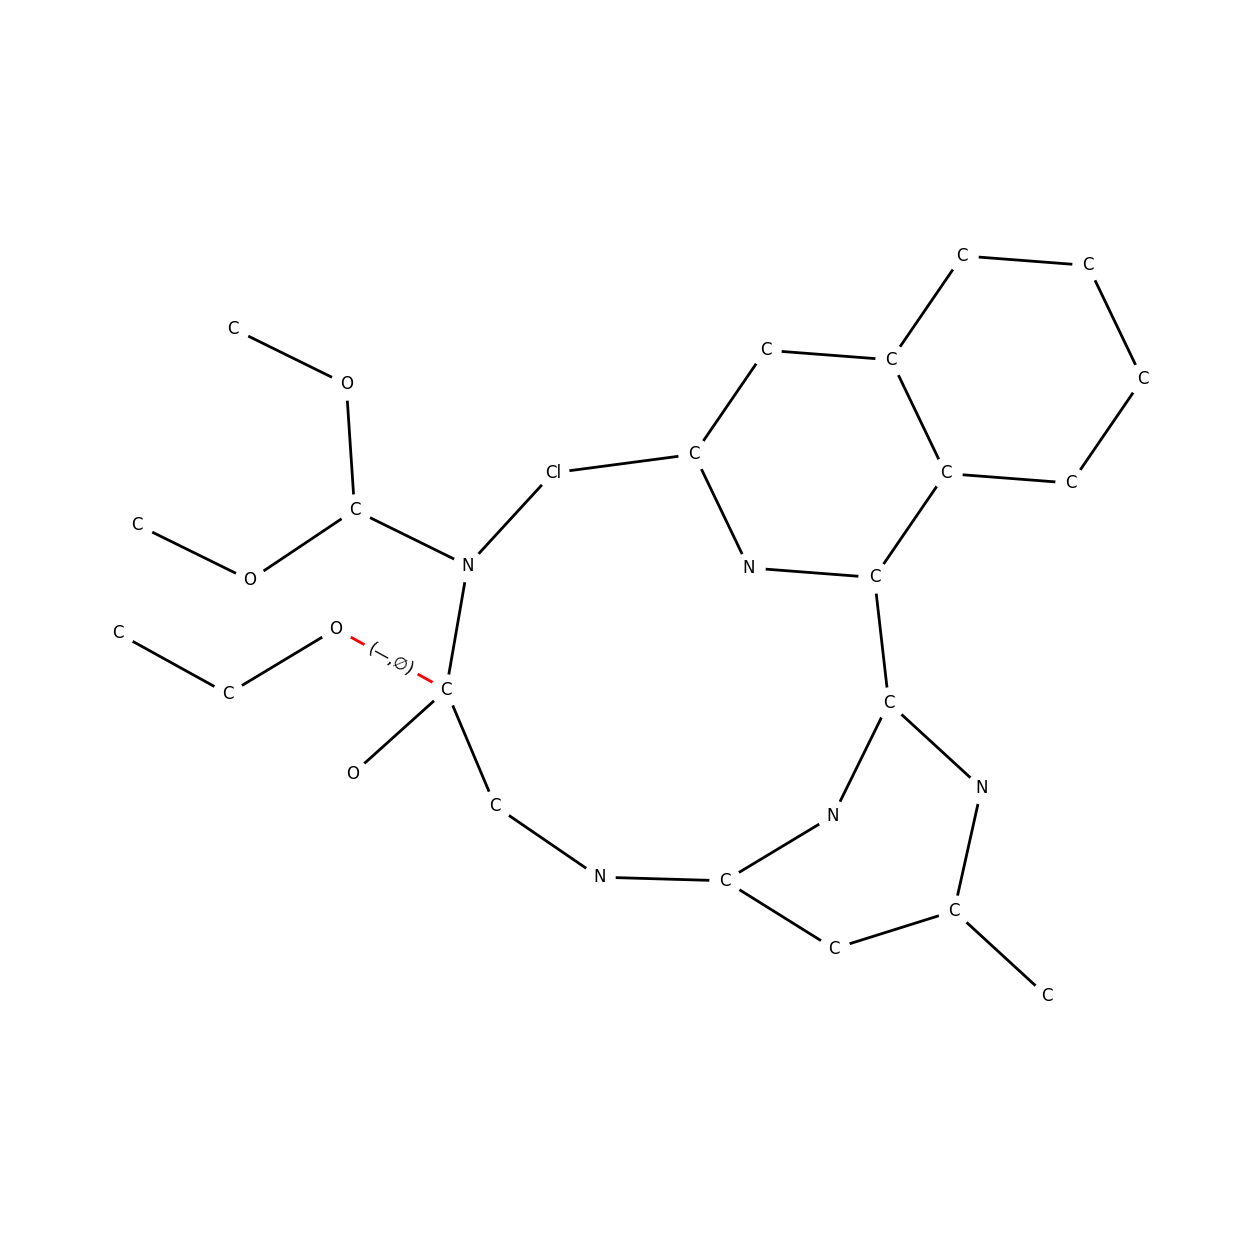

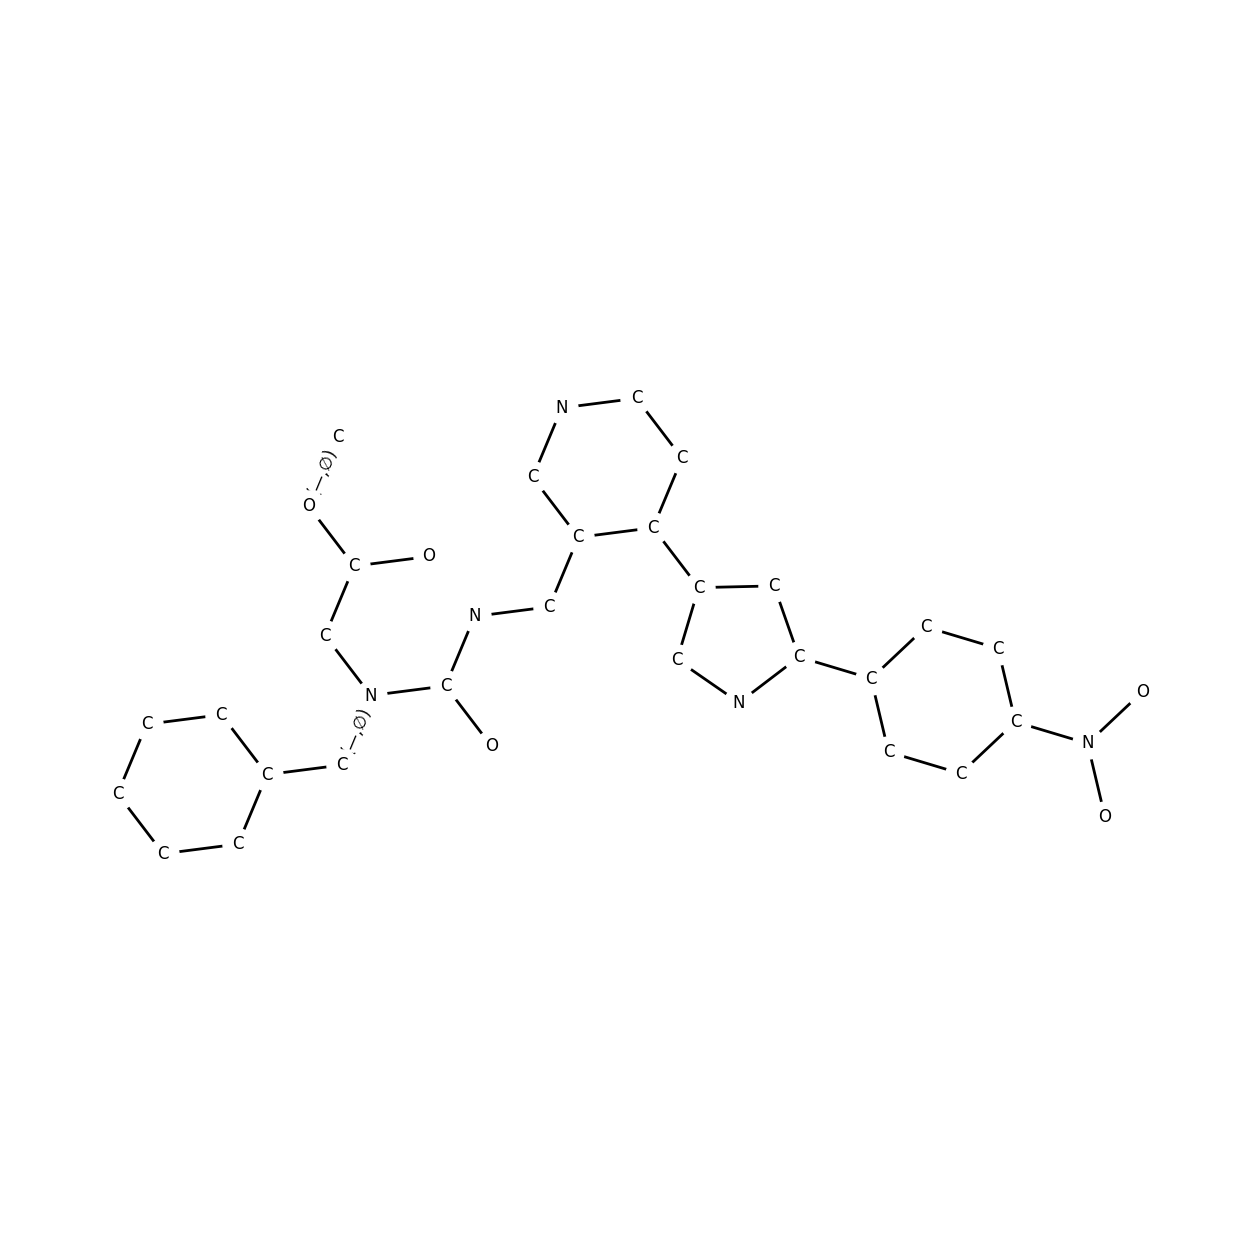

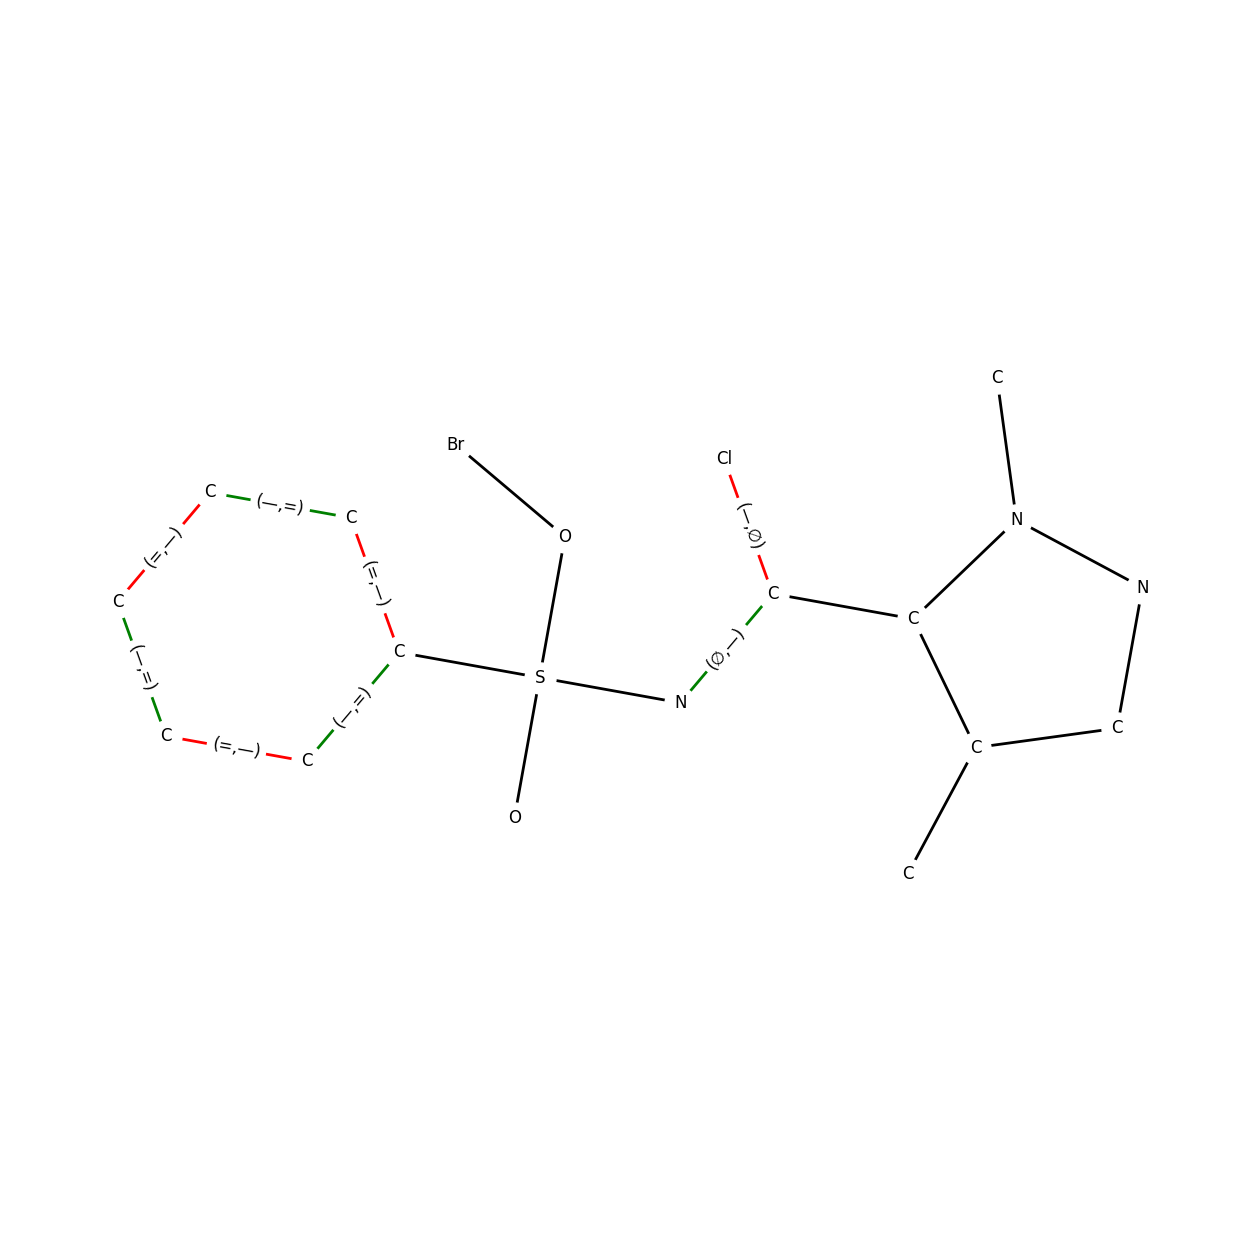

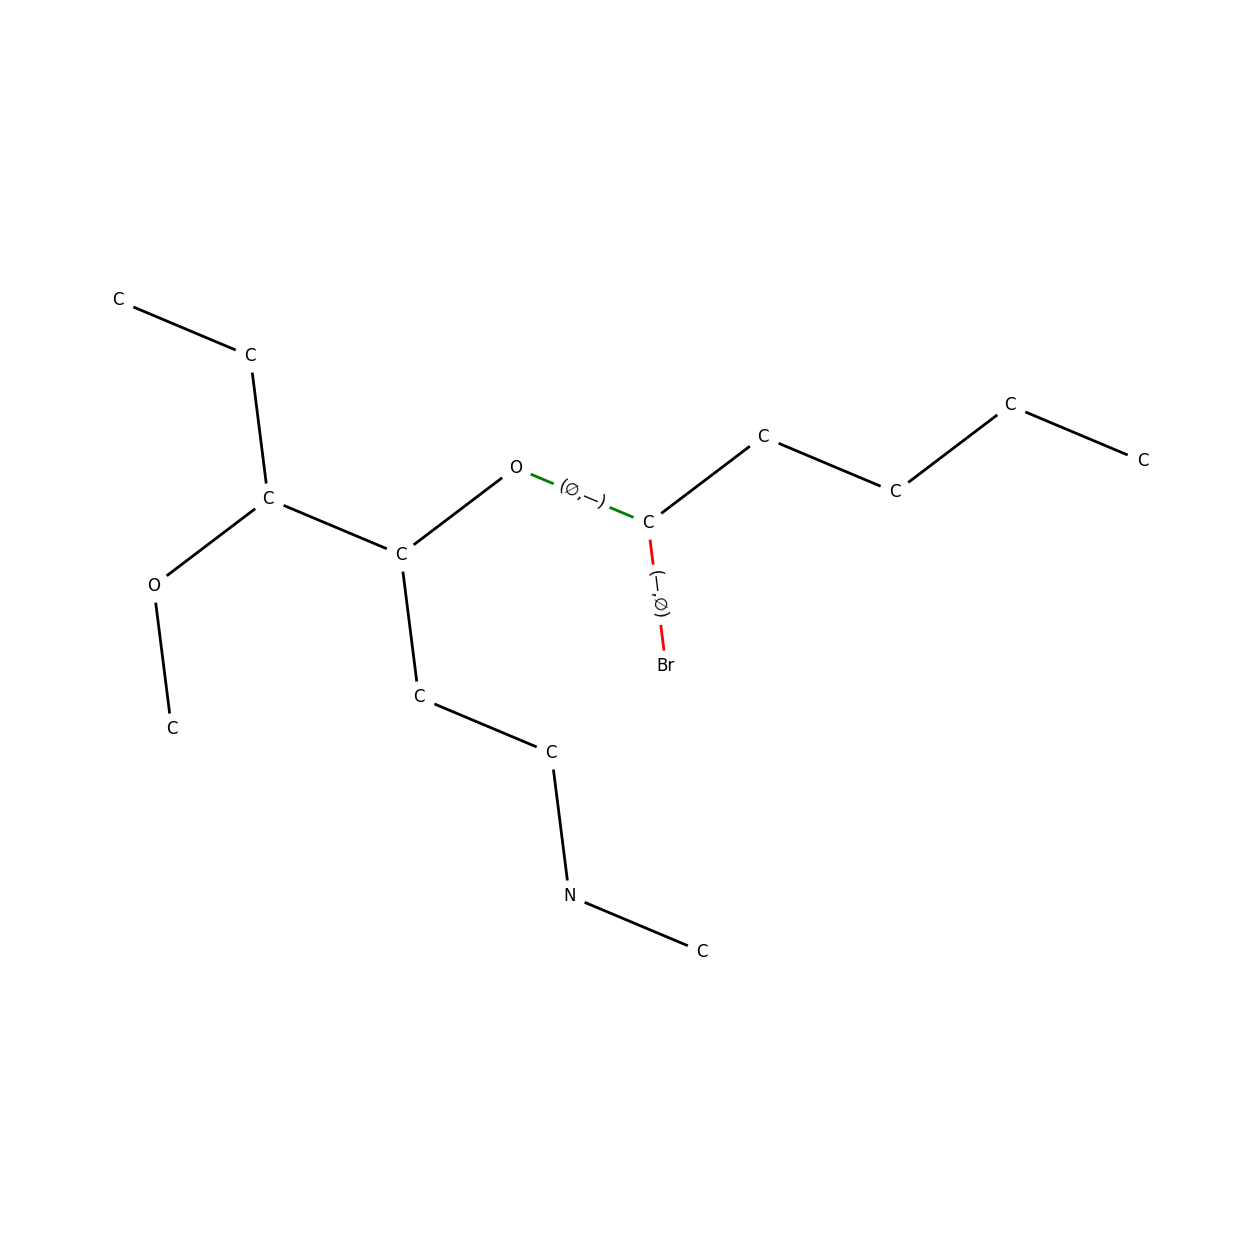

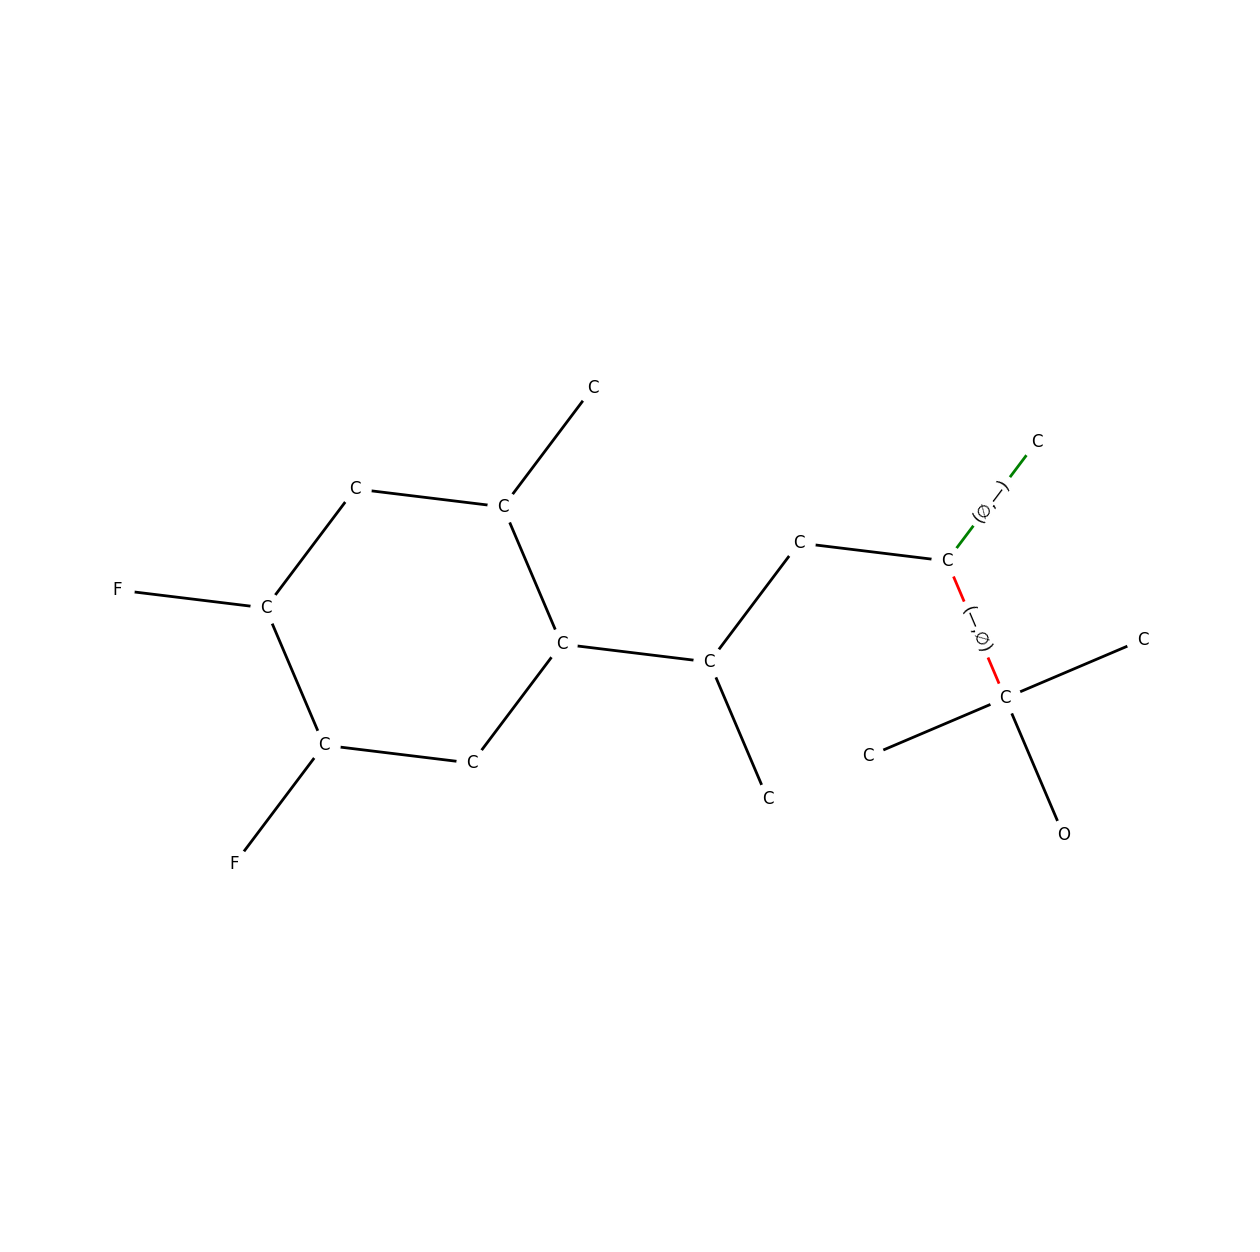

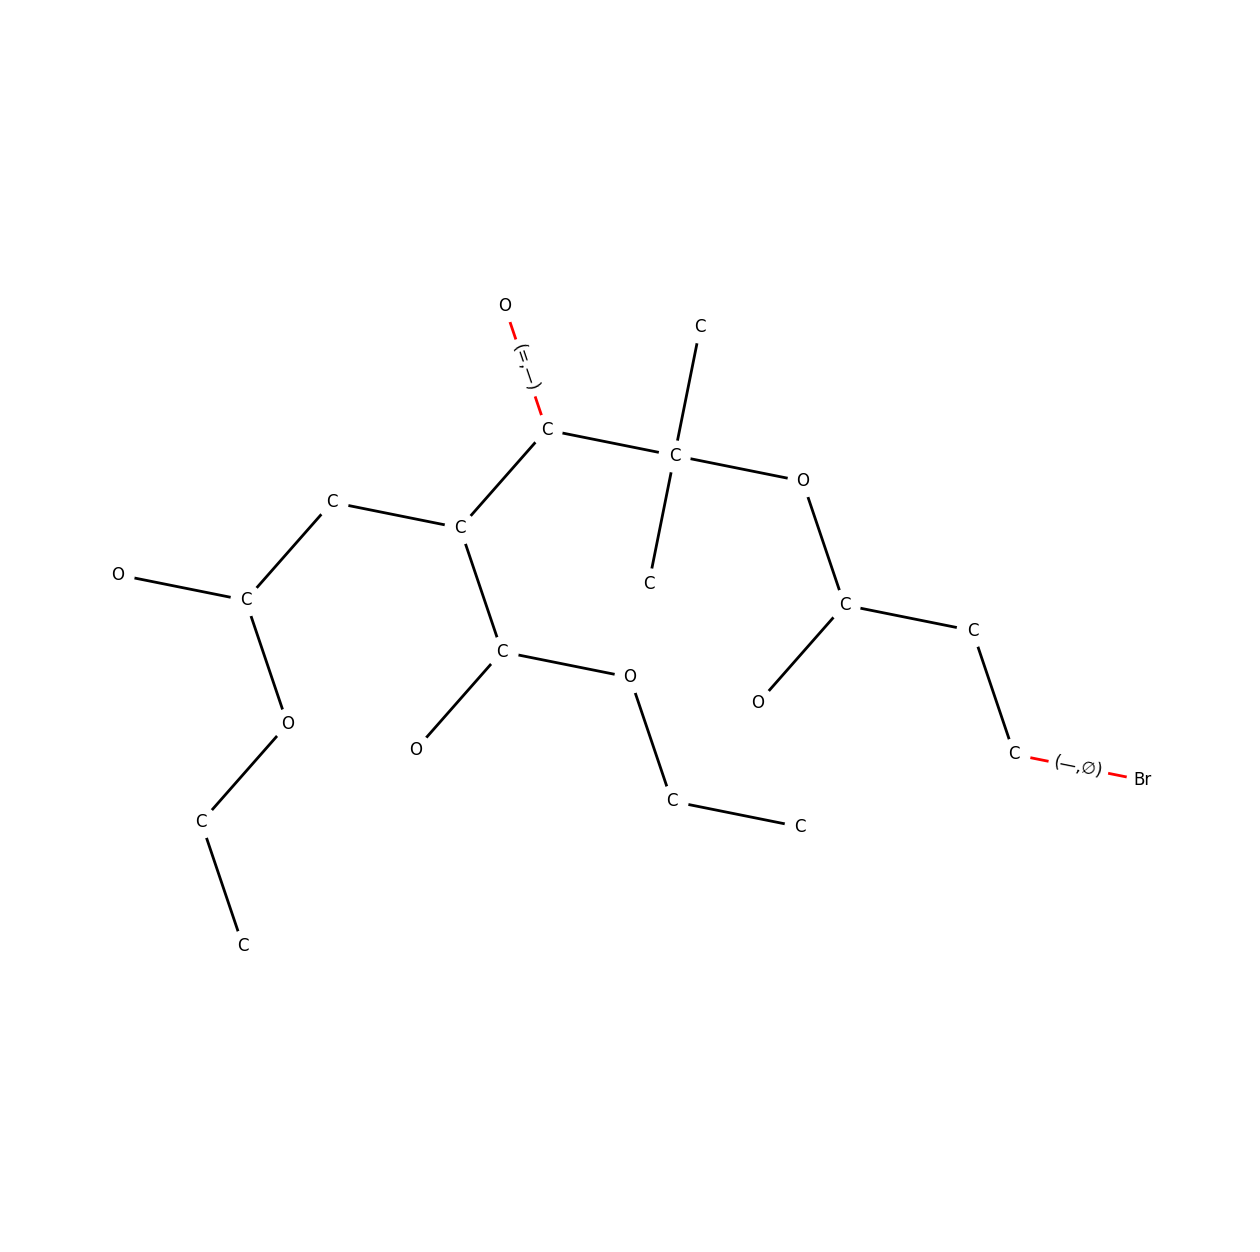

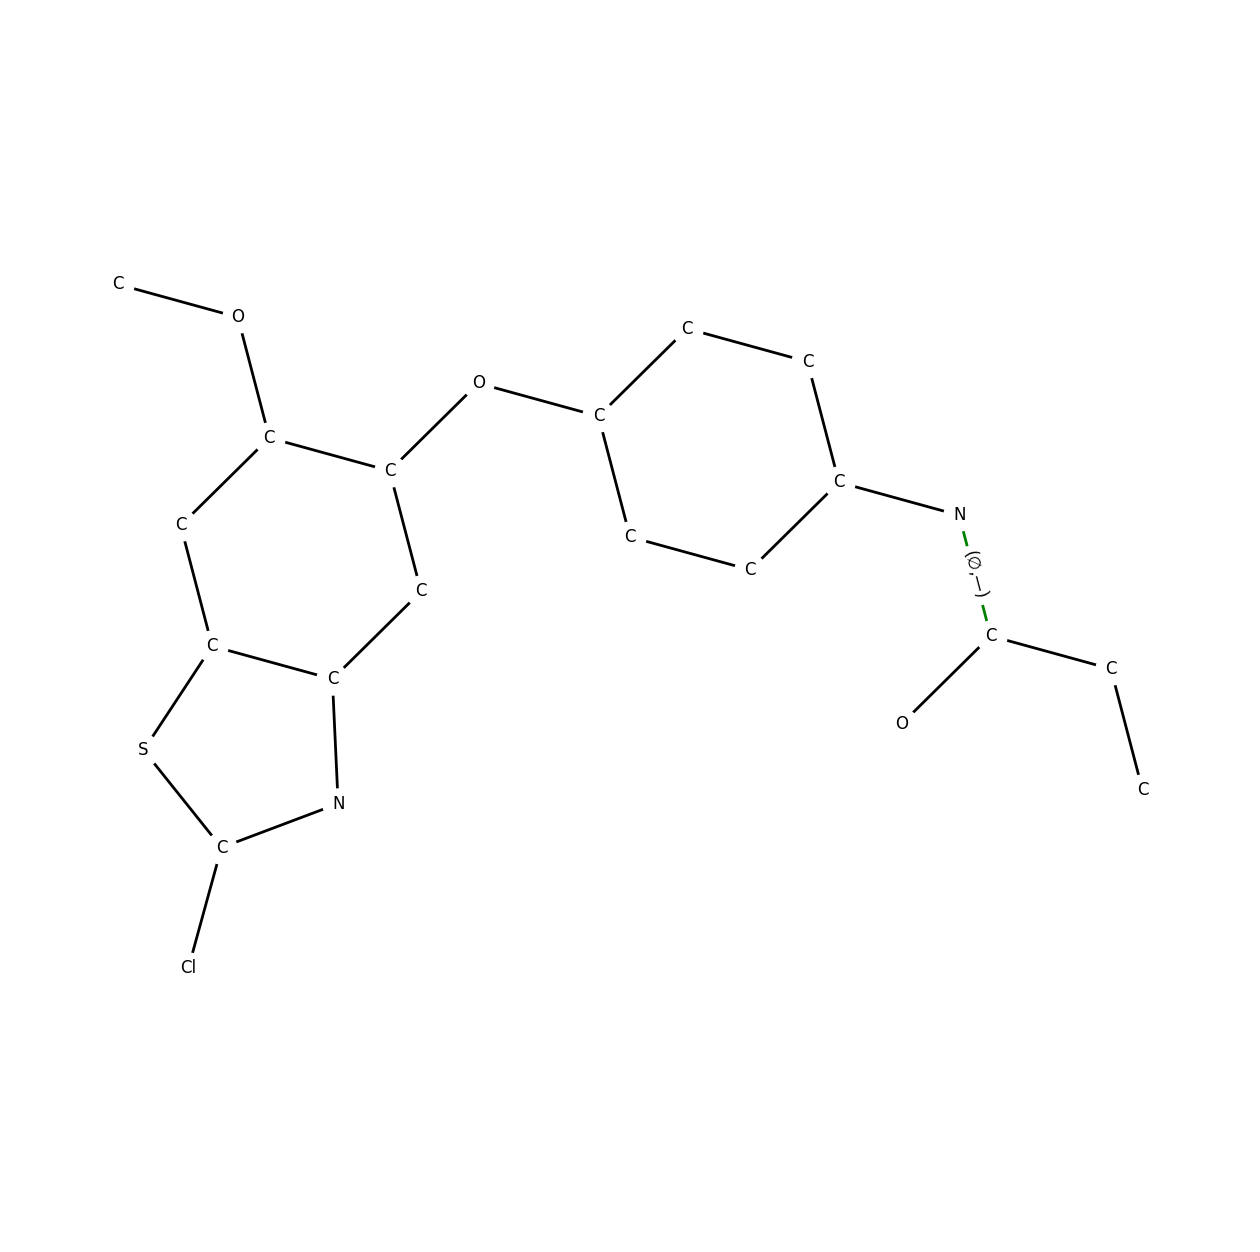

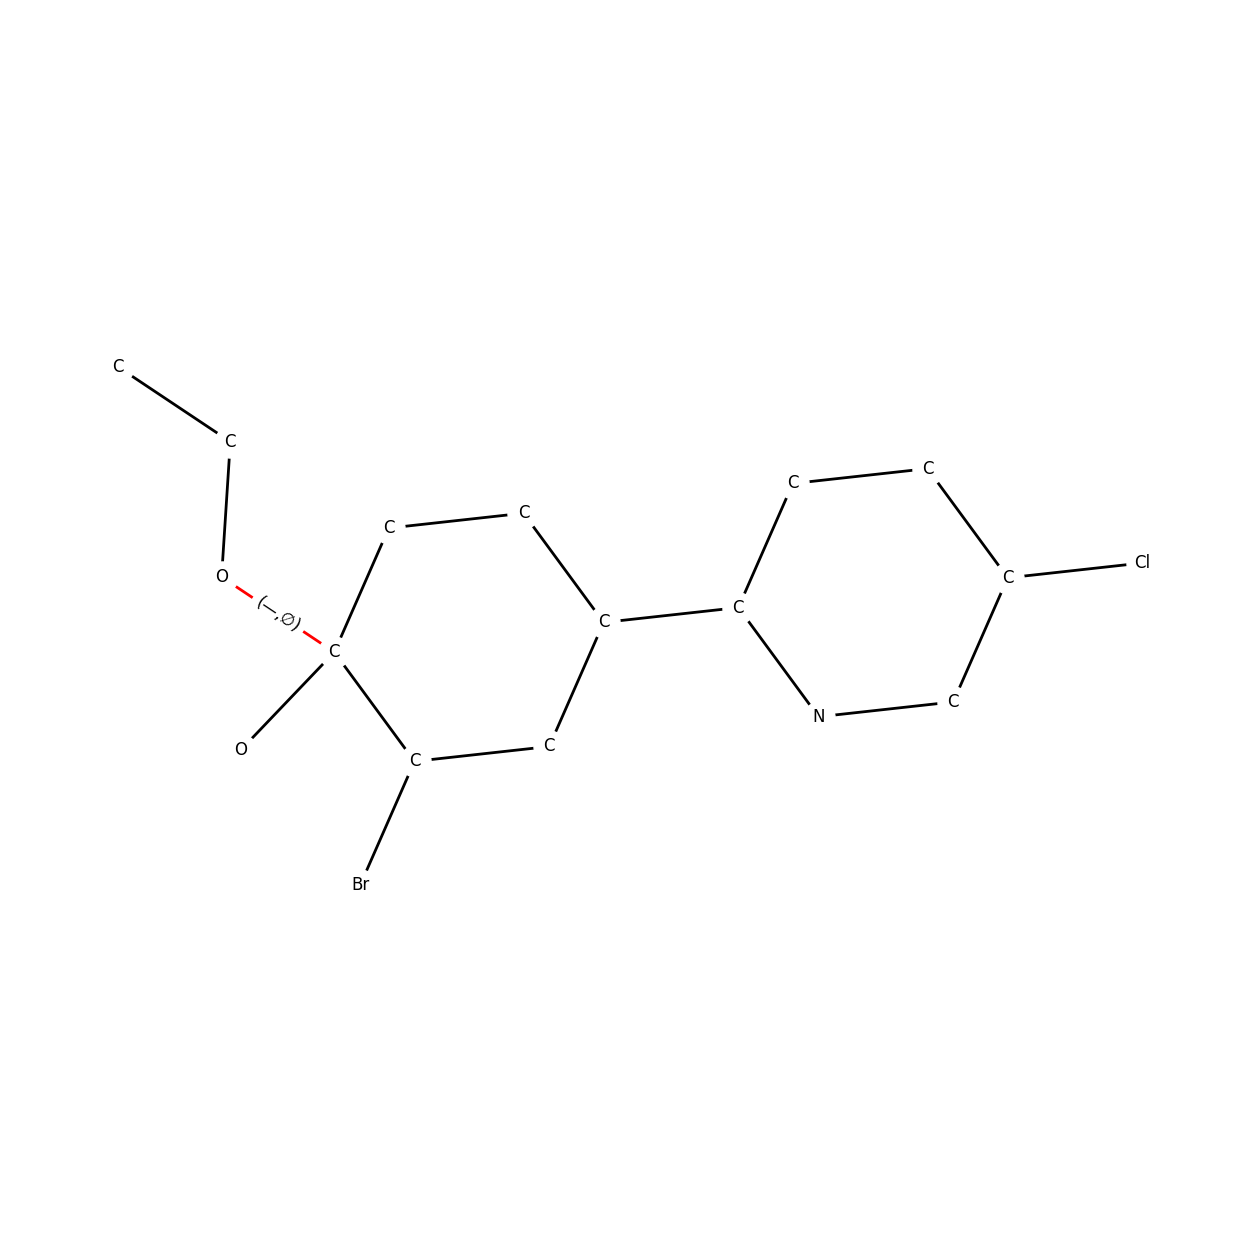

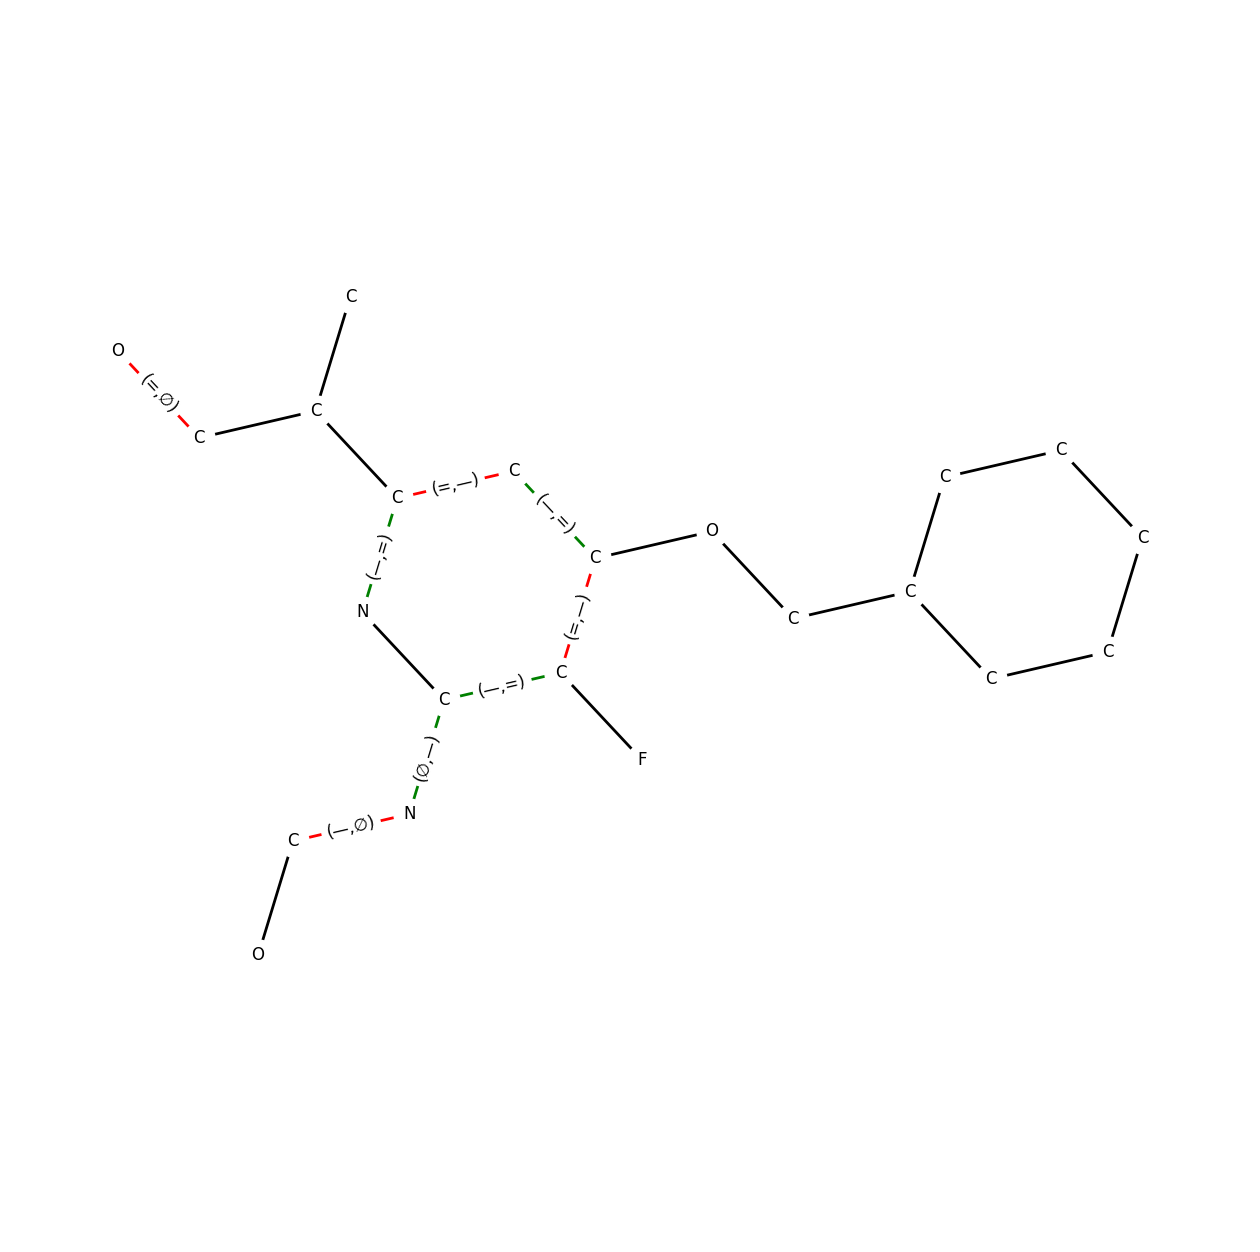

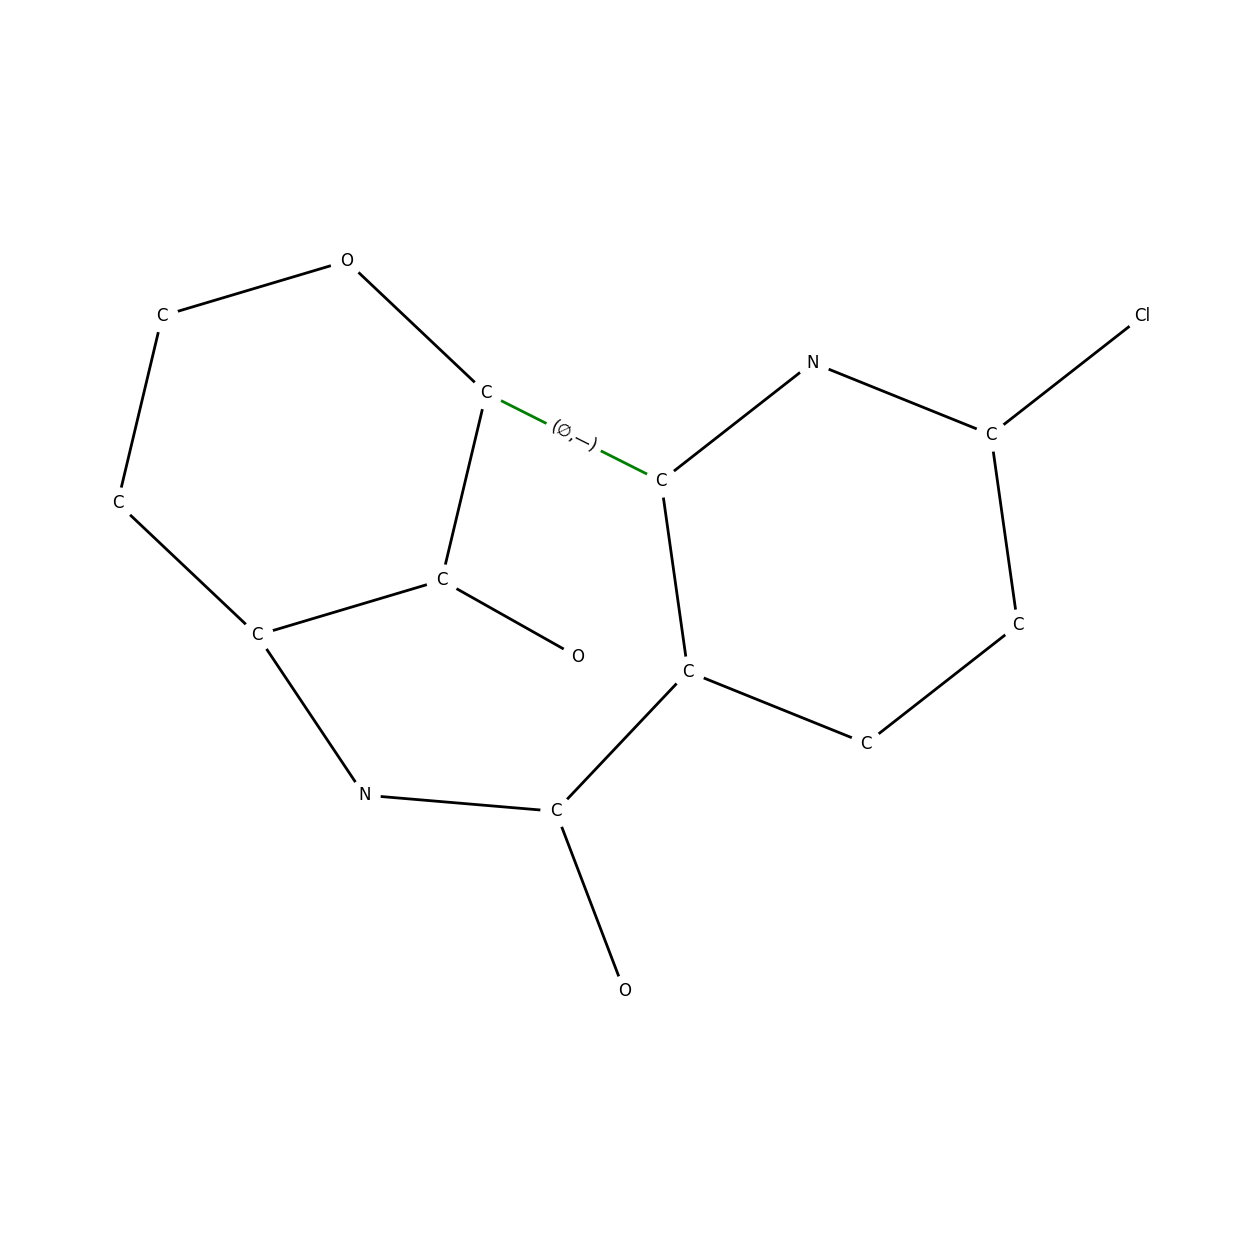

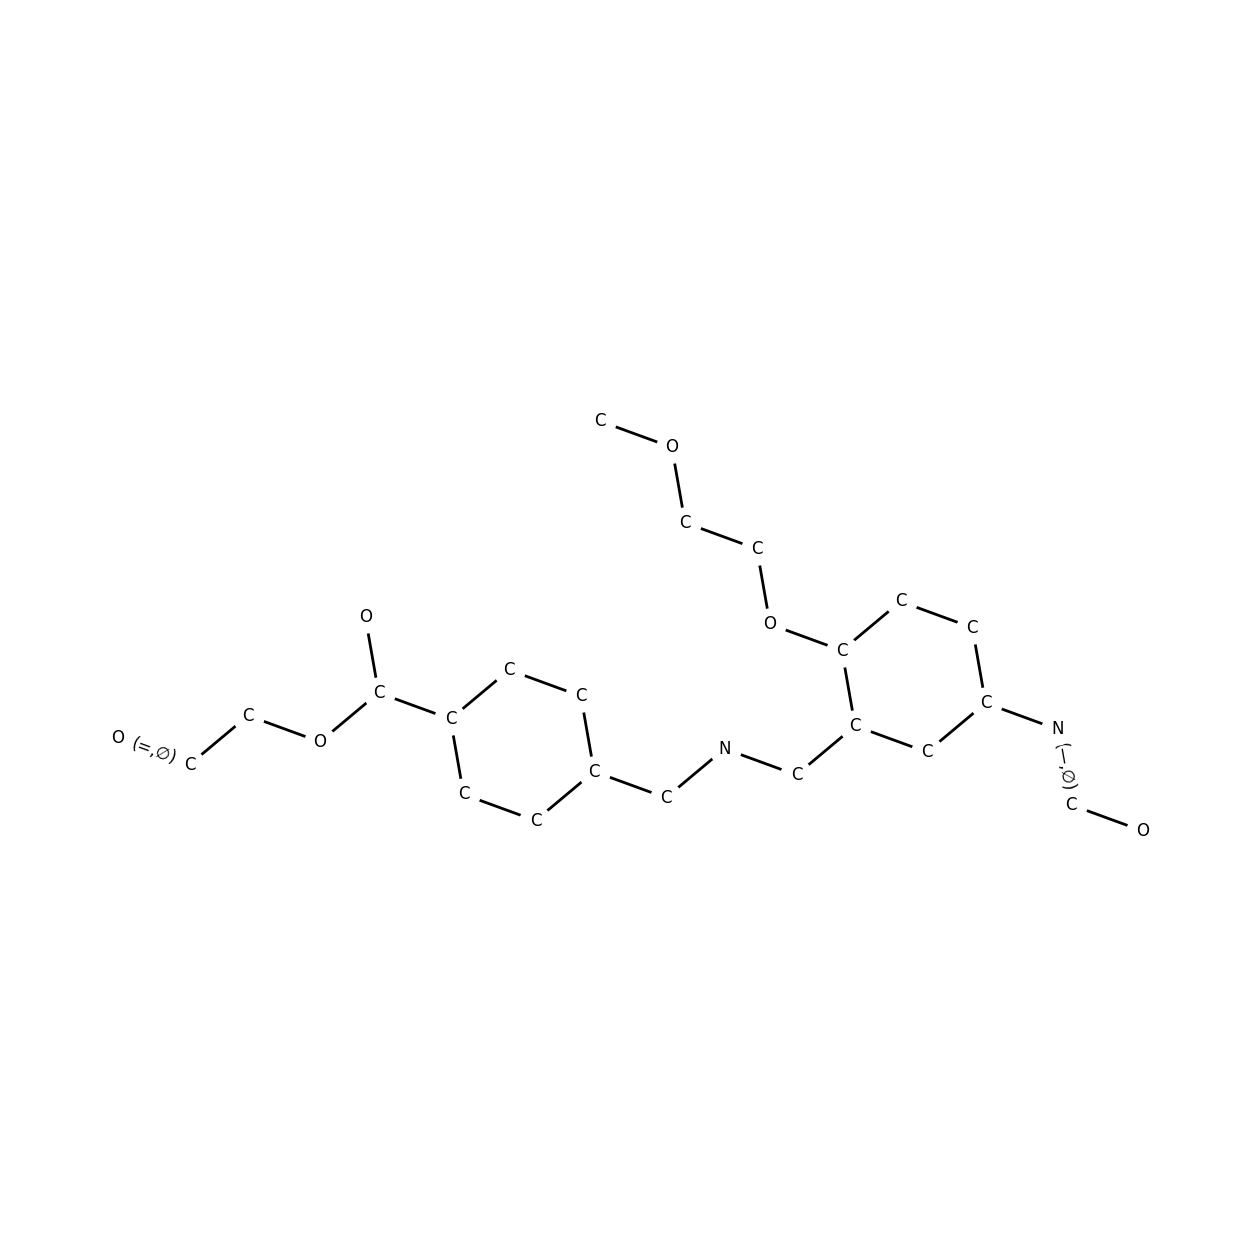

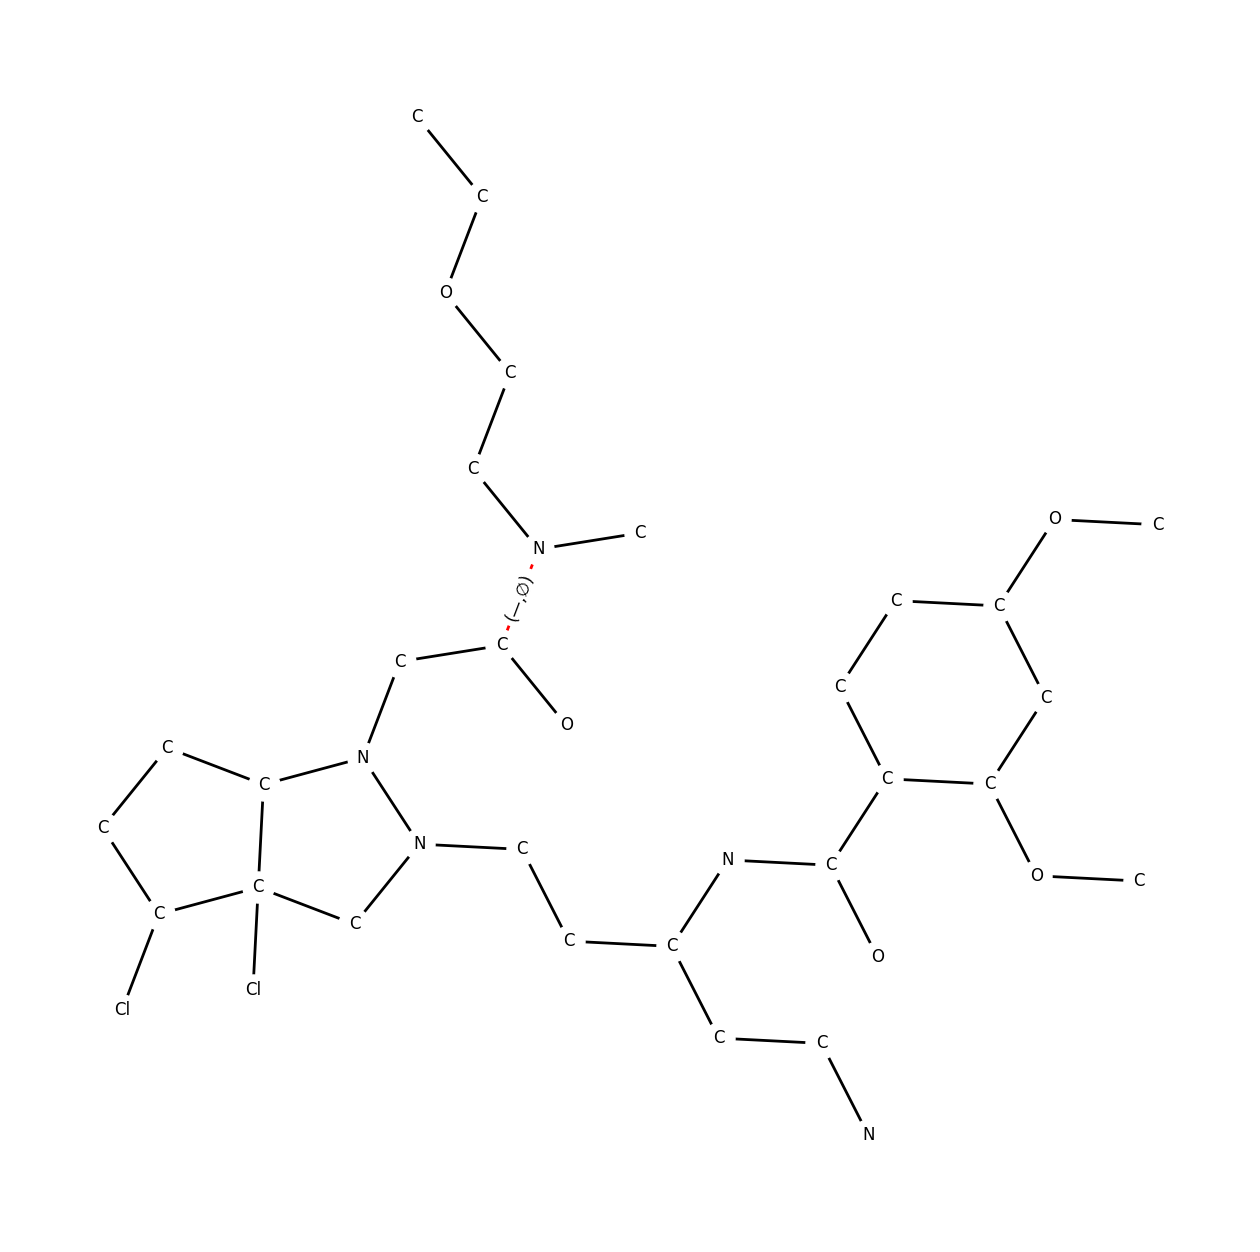

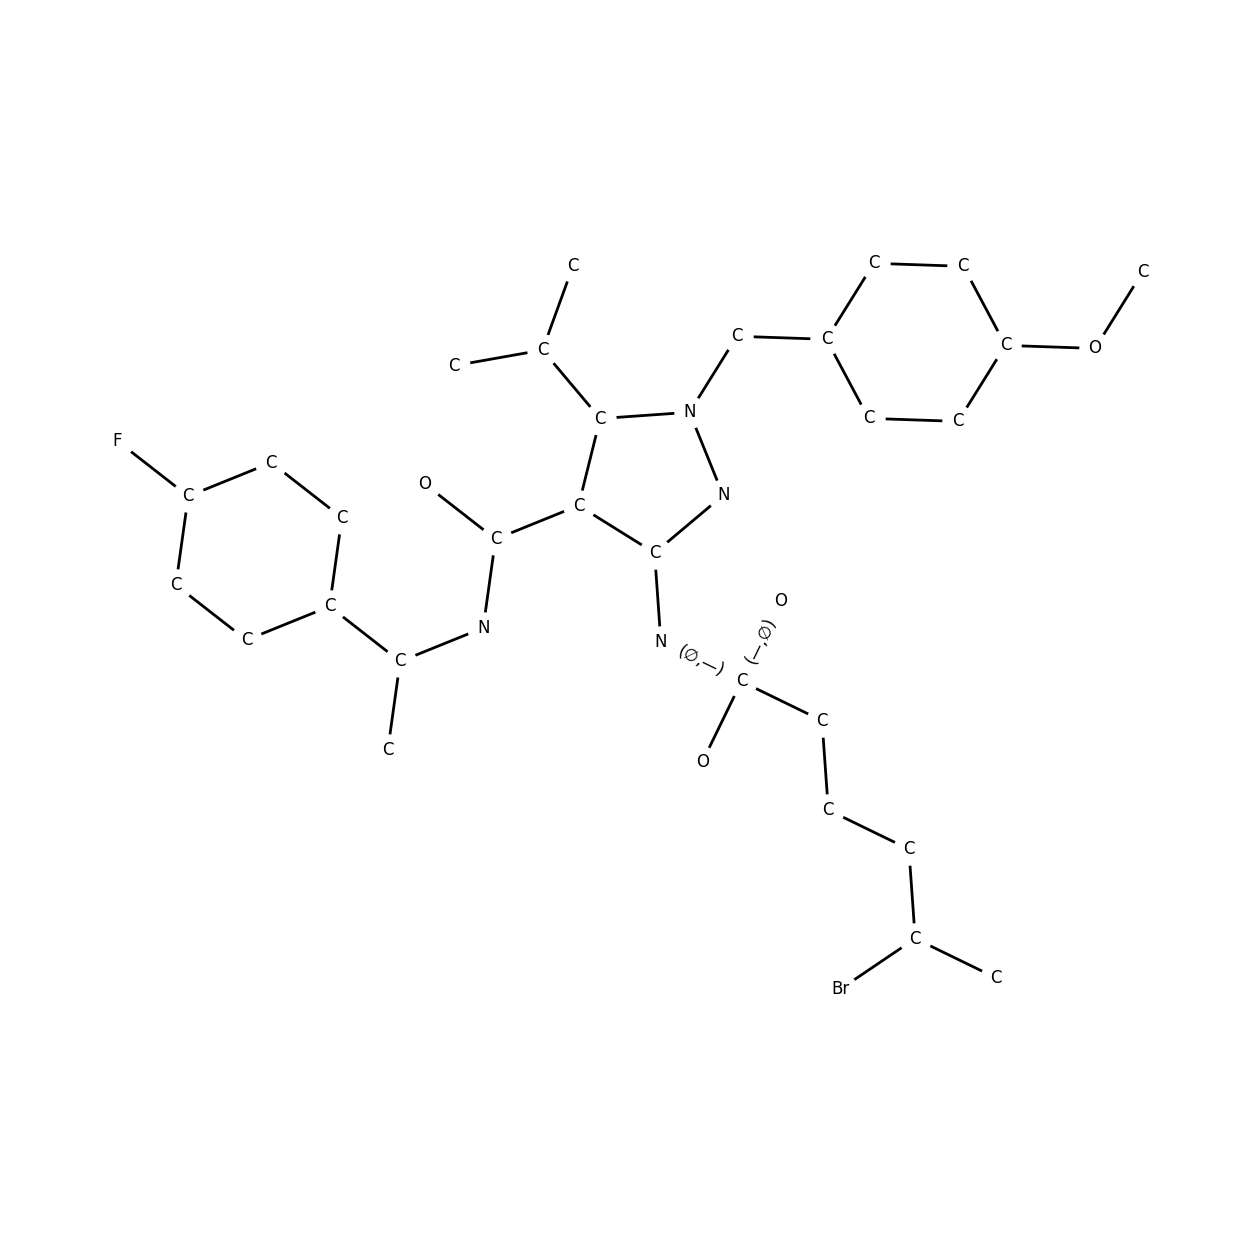

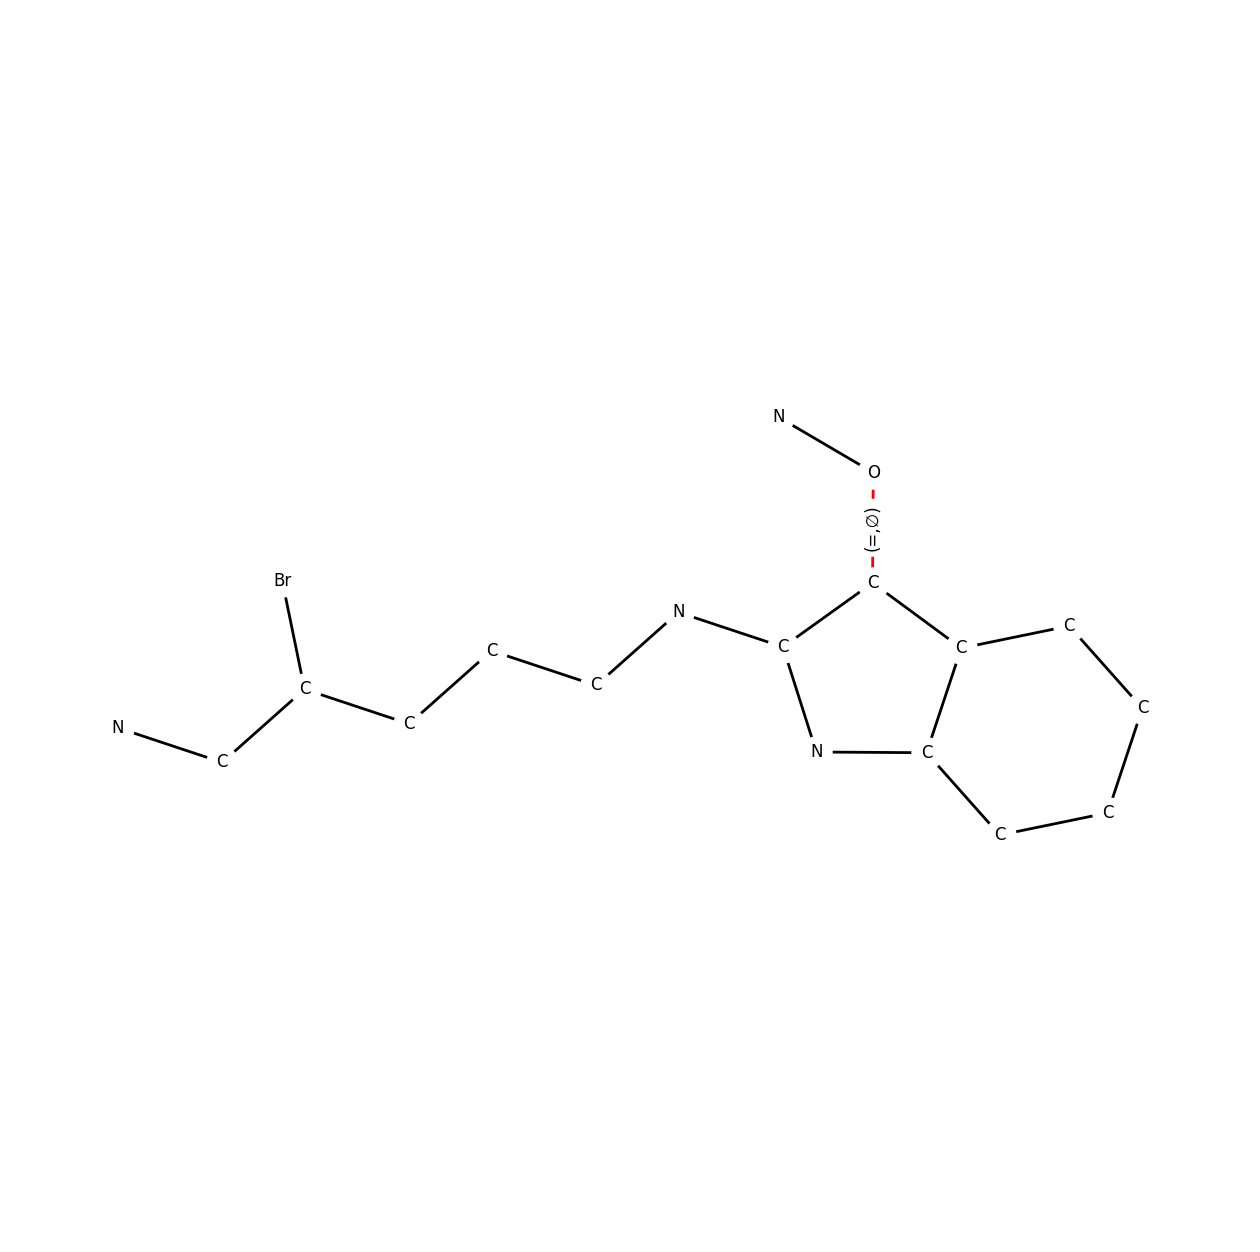

In [9]:
%pip install -qq synkit

from synkit.Vis import GraphVisualizer
import matplotlib.pyplot as plt
from graphies import Graphies
import networkx as nx

gf = Graphies(GRAMMAR_PATH)
vis = GraphVisualizer()

for seq in sequences:
  its = gf.decode(tokenizer.strip(seq))
  nx.set_edge_attributes(its, {
      (u, v): {'standard_order': edge["order"][0] - edge["order"][1]}
      for u, v, edge in its.edges(data=True)
  })

  fig, axes = plt.subplots(1, 1, figsize=(16, 16))
  vis.plot_its(its, axes, use_edge_color=True)
  plt.show()
